In [3]:
!pip install git+https://github.com/flatironinstitute/CaImAn.git tifffile scikit-image --quiet

import os
import sys
import time
import json
import warnings
warnings.filterwarnings("ignore")

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tifffile
from pathlib import Path

import skimage.transform
from skimage.morphology import convex_hull_image
from scipy.optimize import linear_sum_assignment

import caiman as cm
from caiman.source_extraction.cnmf import cnmf as cnmf_module
from caiman.source_extraction.cnmf import params as params_module

OUTPUT_DIR = "/content/cnmf_results"
Path(OUTPUT_DIR).mkdir(exist_ok=True)

print(f"Output directory: {OUTPUT_DIR}")

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Output directory: /content/cnmf_results


Mounted at /content/drive
Original  : shape=(60, 2048, 2048)  dtype=uint16
Downsampled: shape=(60, 512, 512)  dtype=float32


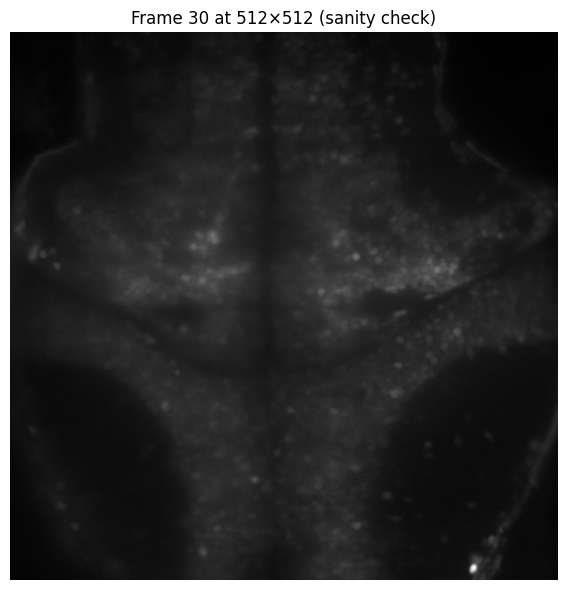

Saved sanity_check_512.png


In [4]:
from google.colab import drive
drive.mount("/content/drive")

FILENAME = "/content/drive/My Drive/Zebra_fish/10vii25_task18_60frames.h5"

with h5py.File(FILENAME, "r") as fh:
    data_full = fh["Data"][:]           # loads full (60, 2048, 2048) uint16 ≈ 480 MB
    shape_orig = data_full.shape
    dtype_orig = data_full.dtype

T_ORIG, H_ORIG, W_ORIG = shape_orig
print(f"Original  : shape={shape_orig}  dtype={dtype_orig}")

# Downsample 4× to 512×512 with anti-aliasing.
# This reduces each CNMF run from ~30 min to ~2-3 min on Colab.
# Side-effect: neuron radii shrink by 4×, so gSig values must be scaled down.
TARGET_H, TARGET_W = 512, 512
data_512 = np.zeros((T_ORIG, TARGET_H, TARGET_W), dtype=np.float32)
for t in range(T_ORIG):
    data_512[t] = skimage.transform.resize(
        data_full[t].astype(np.float32),
        (TARGET_H, TARGET_W),
        anti_aliasing=True,
    )
del data_full   # release 480 MB

T, H, W = data_512.shape
DIMS_512 = (H, W)
print(f"Downsampled: shape={data_512.shape}  dtype={data_512.dtype}")

# Quick sanity check — show middle frame
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(data_512[T // 2], cmap="gray")
ax.set_title(f"Frame {T // 2} at 512×512 (sanity check)")
ax.axis("off")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/sanity_check_512.png", dpi=100)
plt.show()
print("Saved sanity_check_512.png")


In [10]:
import caiman as cm
import caiman.mmapping
import caiman.base.movies

# Patch missing attributes for CaImAn
if not hasattr(cm, 'load'):
    cm.load = cm.base.movies.load
if not hasattr(cm, 'movie'):
    cm.movie = cm.base.movies.movie
if not hasattr(cm, 'paths'):
    import caiman.paths

TIF_PATH  = "/content/fish_512.tif"
MMAP_BASE = "/content/fish_512_mmap"

print("Saving float32 tiff...")
tifffile.imwrite(TIF_PATH, data_512)

print("Converting to CaImAn memmap...")
FNAME_MMAP = caiman.mmapping.save_memmap(
    [TIF_PATH],
    base_name=MMAP_BASE,
    order="C",
    border_to_0=0,
)
print(f"Memmap: {FNAME_MMAP}")

# Verify
Yr_check, dims_check, T_check = caiman.mmapping.load_memmap(FNAME_MMAP)
assert dims_check == DIMS_512, f"Dimension mismatch: {dims_check} vs {DIMS_512}"
assert T_check == T, f"Frame count mismatch: {T_check} vs {T}"
print(f"Verified: Yr={Yr_check.shape}  dims={dims_check}  T={T_check}")

Saving float32 tiff...
Converting to CaImAn memmap...


Memmap: /root/caiman_data/temp/fish_512_mmap_d1_512_d2_512_d3_1_order_C_frames_60.mmap
Verified: Yr=(262144, 60)  dims=(512, 512)  T=60


In [11]:
# ── Default parameters (fixed across all experiments unless overridden) ──────
# method_init='corr_pnr' is the CNMF-E initialization recommended for
# light-sheet calcium imaging. It auto-detects K from min_corr/min_pnr.
# nb=0 / nb_patch=0: no global background (ring model handles it locally).
# With only 60 frames, temporal statistics (PNR, AR model) are noisier than
# typical recordings; treat Experiment 4 (p value) as exploratory.
BASE_PARAMS = {
    "fr": 5,
    "decay_time": 1.0,
    "method_init": "corr_pnr",
    "K": None,              # auto-determine neuron count per patch
    "nb": 0,                # no global background components
    "nb_patch": 0,
    "center_psf": True,
    "ring_size_factor": 1.4,
    "merge_thr": 0.85,
    "use_cnn": False,       # skip CNN classifier — not reliable on 60 frames
    "min_SNR": 1.5,
    "rval_thr": 0.85,
    "del_duplicates": True,
    "ssub": 1,              # no spatial subsampling (already at 512×512)
    "tsub": 1,              # no temporal subsampling
    "only_init": False,
}


def array_to_memmap(array, basename):
    """Convert (T, H, W) float32 array to a CaImAn memmap. Returns the mmap filename."""
    tif_path = f"{basename}.tif"
    tifffile.imwrite(tif_path, array.astype(np.float32))
    fname = caiman.mmapping.save_memmap([tif_path], base_name=basename, order="C", border_to_0=0)
    return fname


def run_cnmf(params_override, fname_mmap):
    """
    Merge BASE_PARAMS with params_override, run CNMF on fname_mmap.
    Returns (cnmf_obj or None, runtime_seconds).
    gSig can be passed as a scalar int; it is auto-converted to a tuple
    and gSiz is derived as (4*gSig+1, 4*gSig+1).
    """
    p = {**BASE_PARAMS, **params_override, "fnames": [fname_mmap]}

    g = p["gSig"]
    if isinstance(g, (int, float)):
        g = int(g)
        p["gSig"] = (g, g)
        p["gSiz"] = (4 * g + 1, 4 * g + 1)

    opts = params_module.CNMFParams(params_dict=p)
    cnmf_obj = cnmf_module.CNMF(n_processes=1, params=opts)

    t0 = time.time()
    try:
        cnmf_obj.fit_file(motion_correct=False)
        return cnmf_obj, time.time() - t0
    except Exception as exc:
        print(f"    CNMF failed: {exc}")
        return None, time.time() - t0


def score_run(cnmf_obj, Yr):
    """
    Compute three unsupervised quality metrics for a CNMF run.
    Yr: (d1*d2, T) memmap as returned by caiman.mmapping.load_memmap.

    Returns dict:
        n_neurons         — number of detected components
        recon_error       — ||Y - Â*Ĉ|| / ||Y||  (lower is better)
        spatial_compactness — mean(footprint_area / convex_hull_area)  (higher is better)
        trace_sparsity    — mean L1/L2 norm of calcium traces  (lower = more spike-like)
    """
    sentinel = {
        "n_neurons": 0,
        "recon_error": 1.0,
        "spatial_compactness": 0.0,
        "trace_sparsity": float("inf"),
    }
    if cnmf_obj is None:
        return sentinel

    A = cnmf_obj.estimates.A   # (d1*d2, n)  sparse
    C = cnmf_obj.estimates.C   # (n, T)
    n_neurons = A.shape[1]
    if n_neurons == 0:
        return sentinel

    # Reconstruction error ─────────────────────────────────────────────────
    Y_hat = A @ C
    b = getattr(cnmf_obj.estimates, "b", None)
    f_bg = getattr(cnmf_obj.estimates, "f", None)
    if b is not None and f_bg is not None and b.shape[1] > 0:
        Y_hat = Y_hat + b @ f_bg

    recon_error = float(
        np.linalg.norm(Yr - Y_hat, "fro") / (np.linalg.norm(Yr, "fro") + 1e-9)
    )

    # Spatial compactness ──────────────────────────────────────────────────
    H_val, W_val = DIMS_512
    compactness_list = []
    for i in range(n_neurons):
        fp = np.asarray(A[:, i].todense()).flatten().reshape(H_val, W_val)
        binary = fp > (fp.max() * 0.2)
        if binary.sum() < 5:
            continue
        try:
            hull = convex_hull_image(binary)
            compactness_list.append(float(binary.sum()) / float(hull.sum()))
        except Exception:
            pass
    spatial_compactness = float(np.mean(compactness_list)) if compactness_list else 0.0

    # Trace sparsity ───────────────────────────────────────────────────────
    l1 = np.sum(np.abs(C), axis=1)
    l2 = np.linalg.norm(C, axis=1)
    trace_sparsity = float(np.mean(l1 / (l2 + 1e-9)))

    return {
        "n_neurons": n_neurons,
        "recon_error": recon_error,
        "spatial_compactness": spatial_compactness,
        "trace_sparsity": trace_sparsity,
    }


def compute_stability(A1, A2, threshold=0.5):
    """
    Fraction of neurons in A1 that have a matched counterpart in A2
    with spatial correlation >= threshold (Hungarian matching).
    A1, A2: sparse matrices (d1*d2, n_i).
    """
    if A1 is None or A2 is None or A1.shape[1] == 0 or A2.shape[1] == 0:
        return 0.0

    norms1 = np.asarray(np.sqrt(A1.power(2).sum(axis=0))).flatten() + 1e-9
    norms2 = np.asarray(np.sqrt(A2.power(2).sum(axis=0))).flatten() + 1e-9
    A1n = A1.multiply(1.0 / norms1)
    A2n = A2.multiply(1.0 / norms2)

    corr = np.asarray((A1n.T @ A2n).todense())   # (n1, n2)
    row_ind, col_ind = linear_sum_assignment(-corr)
    matched = corr[row_ind, col_ind]
    return float(np.mean(matched >= threshold))


print("Helper functions defined.")



Helper functions defined.


EXPERIMENT 1: gSig sweep  [1, 2, 3, 4]
  gSig=1 ... 

neurons=   0  recon_err=1.000  compactness=0.000  t=99s
  gSig=2 ... 

neurons=   0  recon_err=1.000  compactness=0.000  t=145s
  gSig=3 ... 

neurons=   3  recon_err=0.998  compactness=0.914  t=158s
  gSig=4 ... 

neurons=   4  recon_err=0.998  compactness=0.899  t=174s

  gSig  n_neurons  recon_error  spatial_compactness  trace_sparsity
    1          0     1.000000             0.000000             inf
    2          0     1.000000             0.000000             inf
    3          3     0.998161             0.914495        7.737147
    4          4     0.997695             0.898998        7.738171


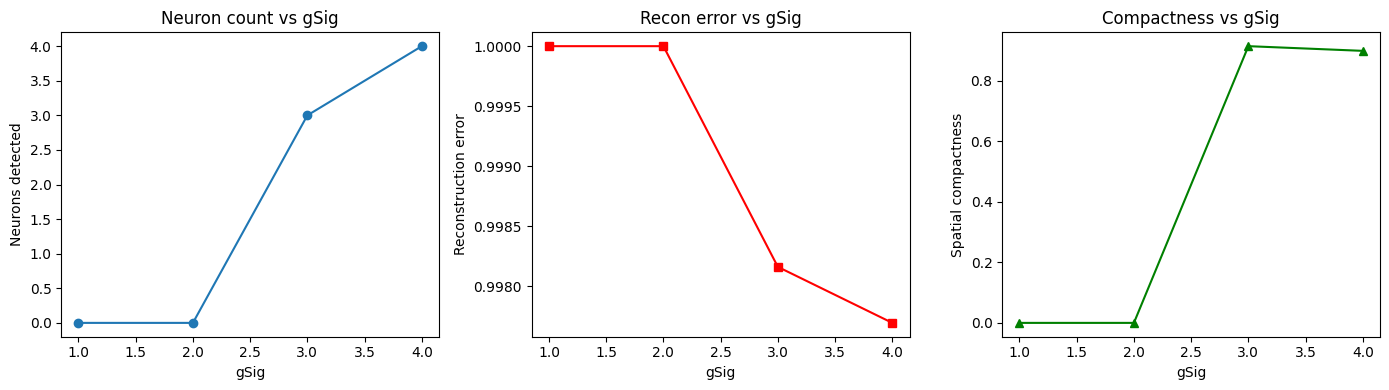


Best gSig = 4


In [13]:
#Goal: find the neuron radius that best describes cells in the downsampled data.
#
# At 512×512 (4× spatial shrink), a neuron of radius 5 px at 2048×2048
# appears as radius ~1.25 px. Sweeping [1, 2, 3, 4] covers the plausible range.
# Too small → neurons fragment into single pixels.
# Too large → distinct neurons merge into one component.
# =============================================================================

print("=" * 60)
print("EXPERIMENT 1: gSig sweep  [1, 2, 3, 4]")
print("=" * 60)

GSIG_VALUES = [1, 2, 3, 4]
EXP1_FIXED  = {"min_corr": 0.8, "min_pnr": 10, "rf": 40, "stride": 20, "p": 1}

Yr_global, _, _ = caiman.mmapping.load_memmap(FNAME_MMAP)

exp1_results = []
for g in GSIG_VALUES:
    print(f"  gSig={g} ...", end=" ", flush=True)
    cnmf_obj, runtime = run_cnmf({**EXP1_FIXED, "gSig": g}, FNAME_MMAP)
    metrics = score_run(cnmf_obj, Yr_global)
    metrics.update({"gSig": g, "runtime_s": round(runtime, 1)})
    exp1_results.append(metrics)
    print(
        f"neurons={metrics['n_neurons']:4d}  "
        f"recon_err={metrics['recon_error']:.3f}  "
        f"compactness={metrics['spatial_compactness']:.3f}  "
        f"t={runtime:.0f}s"
    )

df1 = pd.DataFrame(exp1_results)
df1.to_csv(f"{OUTPUT_DIR}/exp1_gsig_sweep.csv", index=False)
print("\n", df1[["gSig", "n_neurons", "recon_error", "spatial_compactness", "trace_sparsity"]].to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].plot(df1["gSig"], df1["n_neurons"], "o-")
axes[0].set_xlabel("gSig"); axes[0].set_ylabel("Neurons detected")
axes[0].set_title("Neuron count vs gSig")

axes[1].plot(df1["gSig"], df1["recon_error"], "s-", color="red")
axes[1].set_xlabel("gSig"); axes[1].set_ylabel("Reconstruction error")
axes[1].set_title("Recon error vs gSig")

axes[2].plot(df1["gSig"], df1["spatial_compactness"], "^-", color="green")
axes[2].set_xlabel("gSig"); axes[2].set_ylabel("Spatial compactness")
axes[2].set_title("Compactness vs gSig")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/exp1_gsig_sweep.png", dpi=120)
plt.show()

# Select the gSig with lowest reconstruction error
BEST_GSIG = int(df1.loc[df1["recon_error"].idxmin(), "gSig"])
print(f"\nBest gSig = {BEST_GSIG}")



EXPERIMENT 2: min_corr × min_pnr grid search
  min_corr=0.6  min_pnr=5 ... 

neurons=  60  recon_err=0.950
  min_corr=0.6  min_pnr=8 ... 

neurons=   7  recon_err=0.995
  min_corr=0.6  min_pnr=10 ... 

neurons=   4  recon_err=0.998
  min_corr=0.7  min_pnr=5 ... 

neurons=  60  recon_err=0.950
  min_corr=0.7  min_pnr=8 ... 

neurons=   7  recon_err=0.995
  min_corr=0.7  min_pnr=10 ... 

neurons=   4  recon_err=0.998
  min_corr=0.8  min_pnr=5 ... 

neurons=  57  recon_err=0.952
  min_corr=0.8  min_pnr=8 ... 

neurons=   7  recon_err=0.995
  min_corr=0.8  min_pnr=10 ... 

neurons=   4  recon_err=0.998

  min_corr  min_pnr  n_neurons  recon_error
      0.6        5         60     0.949518
      0.7        5         60     0.950056
      0.8        5         57     0.952027
      0.6        8          7     0.994573
      0.8        8          7     0.994573
      0.7        8          7     0.994573
      0.6       10          4     0.997695
      0.7       10          4     0.997695
      0.8       10          4     0.997695


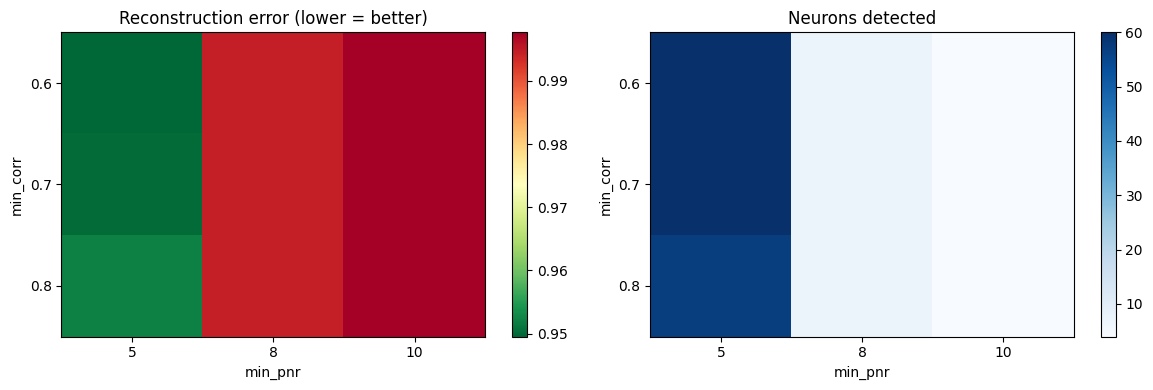


Best min_corr=0.6  min_pnr=5.0


In [14]:
# %% cell5 — EXPERIMENT 2: min_corr × min_pnr GRID SEARCH
# Goal: find the detection threshold pair that balances sensitivity and quality.
#
# Low thresholds → many components including noise.
# High thresholds → missed neurons, fewer false positives.
# The striping artifact visible in Phase 1 may create spuriously high
# correlation pixels, which can inflate neuron counts at low min_corr.
# =============================================================================

print("=" * 60)
print("EXPERIMENT 2: min_corr × min_pnr grid search")
print("=" * 60)

CORR_VALUES = [0.6, 0.7, 0.8]
PNR_VALUES  = [5, 8, 10]
EXP2_FIXED  = {"gSig": BEST_GSIG, "rf": 40, "stride": 20, "p": 1}

exp2_results = []
for corr in CORR_VALUES:
    for pnr in PNR_VALUES:
        print(f"  min_corr={corr}  min_pnr={pnr} ...", end=" ", flush=True)
        cnmf_obj, runtime = run_cnmf(
            {**EXP2_FIXED, "min_corr": corr, "min_pnr": pnr}, FNAME_MMAP
        )
        metrics = score_run(cnmf_obj, Yr_global)
        metrics.update({"min_corr": corr, "min_pnr": pnr, "runtime_s": round(runtime, 1)})
        exp2_results.append(metrics)
        print(f"neurons={metrics['n_neurons']:4d}  recon_err={metrics['recon_error']:.3f}")

df2 = pd.DataFrame(exp2_results)
df2.to_csv(f"{OUTPUT_DIR}/exp2_threshold_grid.csv", index=False)
print("\n", df2[["min_corr", "min_pnr", "n_neurons", "recon_error"]].sort_values("recon_error").to_string(index=False))

pivot_err = df2.pivot(index="min_corr", columns="min_pnr", values="recon_error")
pivot_cnt = df2.pivot(index="min_corr", columns="min_pnr", values="n_neurons")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

im0 = axes[0].imshow(pivot_err.values, cmap="RdYlGn_r", aspect="auto")
axes[0].set_xticks(range(len(PNR_VALUES)));  axes[0].set_xticklabels(PNR_VALUES)
axes[0].set_yticks(range(len(CORR_VALUES))); axes[0].set_yticklabels(CORR_VALUES)
axes[0].set_xlabel("min_pnr"); axes[0].set_ylabel("min_corr")
axes[0].set_title("Reconstruction error (lower = better)")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(pivot_cnt.values, cmap="Blues", aspect="auto")
axes[1].set_xticks(range(len(PNR_VALUES)));  axes[1].set_xticklabels(PNR_VALUES)
axes[1].set_yticks(range(len(CORR_VALUES))); axes[1].set_yticklabels(CORR_VALUES)
axes[1].set_xlabel("min_pnr"); axes[1].set_ylabel("min_corr")
axes[1].set_title("Neurons detected")
plt.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/exp2_threshold_grid_heatmap.png", dpi=120)
plt.show()

best_row2 = df2.loc[df2["recon_error"].idxmin()]
BEST_CORR = float(best_row2["min_corr"])
BEST_PNR  = float(best_row2["min_pnr"])
print(f"\nBest min_corr={BEST_CORR}  min_pnr={BEST_PNR}")



EXPERIMENT 3: rf patch size sweep  [30, 50, 70]
  rf=30 (stride=15) ... 

neurons=  63  recon_err=0.945  t=523s
  rf=50 (stride=25) ... 

neurons=  64  recon_err=0.947  t=488s
  rf=70 (stride=35) ... 

neurons=  59  recon_err=0.941  t=540s

  rf  n_neurons  recon_error  runtime_s
 30         63     0.945245      522.5
 50         64     0.947163      488.4
 70         59     0.940771      540.0


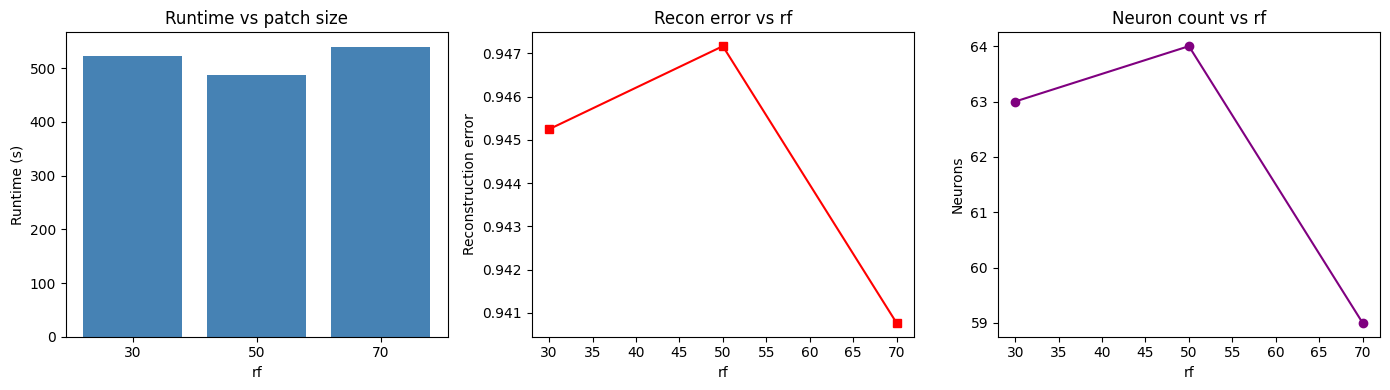


Best rf = 70


In [15]:
# %% cell6 — EXPERIMENT 3: rf PATCH SIZE SWEEP
# Goal: find a patch size that handles the 512×512 image efficiently.
#
# Smaller rf → more, smaller patches → more edge effects but faster per patch.
# Larger rf → fewer, larger patches → better spatial context, longer per patch.
# stride is always set to rf // 2 (50% overlap).
# =============================================================================

print("=" * 60)
print("EXPERIMENT 3: rf patch size sweep  [30, 50, 70]")
print("=" * 60)

RF_VALUES  = [30, 50, 70]
EXP3_FIXED = {"gSig": BEST_GSIG, "min_corr": BEST_CORR, "min_pnr": BEST_PNR, "p": 1}

exp3_results = []
for rf in RF_VALUES:
    print(f"  rf={rf} (stride={rf // 2}) ...", end=" ", flush=True)
    cnmf_obj, runtime = run_cnmf(
        {**EXP3_FIXED, "rf": rf, "stride": rf // 2}, FNAME_MMAP
    )
    metrics = score_run(cnmf_obj, Yr_global)
    metrics.update({"rf": rf, "runtime_s": round(runtime, 1)})
    exp3_results.append(metrics)
    print(f"neurons={metrics['n_neurons']:4d}  recon_err={metrics['recon_error']:.3f}  t={runtime:.0f}s")

df3 = pd.DataFrame(exp3_results)
df3.to_csv(f"{OUTPUT_DIR}/exp3_patch_size.csv", index=False)
print("\n", df3[["rf", "n_neurons", "recon_error", "runtime_s"]].to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].bar([str(r) for r in RF_VALUES], df3["runtime_s"], color="steelblue")
axes[0].set_xlabel("rf"); axes[0].set_ylabel("Runtime (s)")
axes[0].set_title("Runtime vs patch size")

axes[1].plot(df3["rf"], df3["recon_error"], "s-", color="red")
axes[1].set_xlabel("rf"); axes[1].set_ylabel("Reconstruction error")
axes[1].set_title("Recon error vs rf")

axes[2].plot(df3["rf"], df3["n_neurons"], "o-", color="purple")
axes[2].set_xlabel("rf"); axes[2].set_ylabel("Neurons")
axes[2].set_title("Neuron count vs rf")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/exp3_patch_size.png", dpi=120)
plt.show()

BEST_RF = int(df3.loc[df3["recon_error"].idxmin(), "rf"])
print(f"\nBest rf = {BEST_RF}")

EXPERIMENT 4: AR order  +  split-half stability
  p=1 ... 

neurons=  59  recon_err=0.941  sparsity=7.74
  p=2 ... 

neurons=  58  recon_err=0.941  sparsity=7.74

Split-half stability (frames 0-29 vs 30-59)...


  First half : 10 neurons
  Second half: 0 neurons
  Stability score: 0.000  (fraction matched at spatial corr >= 0.5)

  p  n_neurons  recon_error  trace_sparsity  split_half_stability
 1         59     0.940771        7.738944                   0.0
 2         58     0.940816        7.738828                   0.0


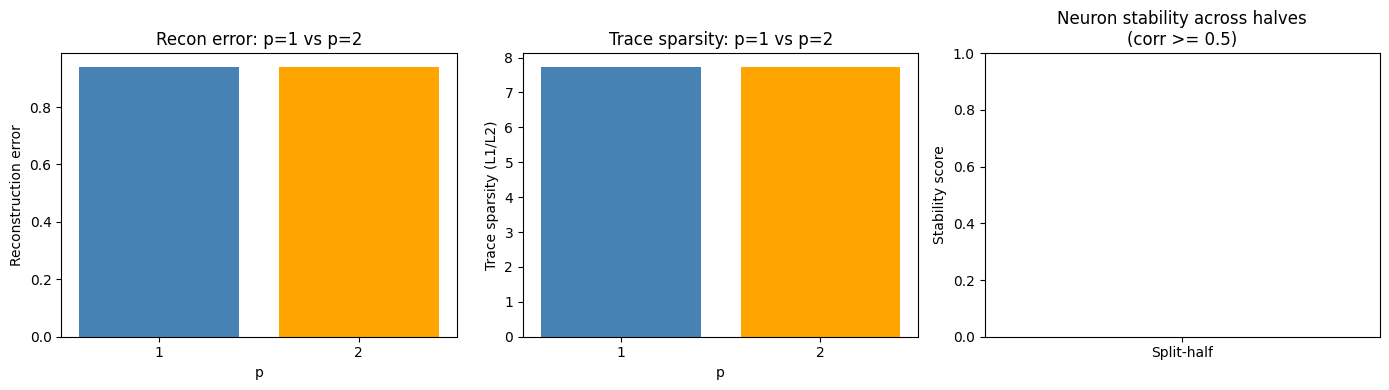


Best p = 1


In [16]:
# %% cell7 — EXPERIMENT 4: AR MODEL ORDER (p=1 vs p=2) + SPLIT-HALF STABILITY
#
# Part A — AR order.
#   p=1: single-exponential calcium decay (simpler, less prone to overfitting).
#   p=2: double-exponential (more realistic but needs more data to fit reliably).
#   With only 60 frames, differences are expected to be subtle.
#   This comparison is exploratory, not definitive.
#
# Part B — Split-half stability (standalone robustness metric).
#   Run CNMF with the best params on frames 0-29 and frames 30-59 separately.
#   Match neurons across halves using spatial correlation (Hungarian algorithm).
#   stability_score = fraction of neurons matched at spatial correlation >= 0.5.
#   A higher score means the detected neurons are consistent across time,
#   suggesting they are real structure rather than noise fits.
#   This metric is independent of p and applies to any parameter combination.
# =============================================================================

print("=" * 60)
print("EXPERIMENT 4: AR order  +  split-half stability")
print("=" * 60)

EXP4_FIXED = {
    "gSig": BEST_GSIG,
    "min_corr": BEST_CORR,
    "min_pnr": BEST_PNR,
    "rf": BEST_RF,
    "stride": BEST_RF // 2,
}

# ── Part A: p=1 vs p=2 ──────────────────────────────────────────────────────
exp4_results = []
for p_val in [1, 2]:
    print(f"  p={p_val} ...", end=" ", flush=True)
    cnmf_obj, runtime = run_cnmf({**EXP4_FIXED, "p": p_val}, FNAME_MMAP)
    metrics = score_run(cnmf_obj, Yr_global)
    metrics.update({"p": p_val, "runtime_s": round(runtime, 1)})
    exp4_results.append(metrics)
    print(f"neurons={metrics['n_neurons']:4d}  recon_err={metrics['recon_error']:.3f}  sparsity={metrics['trace_sparsity']:.2f}")

# ── Part B: split-half stability ─────────────────────────────────────────────
print("\nSplit-half stability (frames 0-29 vs 30-59)...")
fname_first  = array_to_memmap(data_512[:30], "/content/fish_first_half")
fname_second = array_to_memmap(data_512[30:], "/content/fish_second_half")

cnmf_first,  _ = run_cnmf({**EXP4_FIXED, "p": 1}, fname_first)
cnmf_second, _ = run_cnmf({**EXP4_FIXED, "p": 1}, fname_second)

n_first  = cnmf_first.estimates.A.shape[1]  if cnmf_first  else 0
n_second = cnmf_second.estimates.A.shape[1] if cnmf_second else 0
stability = compute_stability(
    cnmf_first.estimates.A  if cnmf_first  else None,
    cnmf_second.estimates.A if cnmf_second else None,
)
print(f"  First half : {n_first} neurons")
print(f"  Second half: {n_second} neurons")
print(f"  Stability score: {stability:.3f}  (fraction matched at spatial corr >= 0.5)")

for row in exp4_results:
    row["split_half_stability"] = round(stability, 3)

df4 = pd.DataFrame(exp4_results)
df4.to_csv(f"{OUTPUT_DIR}/exp4_ar_order.csv", index=False)
print("\n", df4[["p", "n_neurons", "recon_error", "trace_sparsity", "split_half_stability"]].to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
p_labels = [str(int(p)) for p in df4["p"]]

axes[0].bar(p_labels, df4["recon_error"], color=["steelblue", "orange"])
axes[0].set_xlabel("p"); axes[0].set_ylabel("Reconstruction error")
axes[0].set_title("Recon error: p=1 vs p=2")

axes[1].bar(p_labels, df4["trace_sparsity"], color=["steelblue", "orange"])
axes[1].set_xlabel("p"); axes[1].set_ylabel("Trace sparsity (L1/L2)")
axes[1].set_title("Trace sparsity: p=1 vs p=2")

axes[2].bar(["Split-half"], [stability], color="green")
axes[2].set_ylim(0, 1)
axes[2].set_ylabel("Stability score")
axes[2].set_title("Neuron stability across halves\n(corr >= 0.5)")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/exp4_ar_order.png", dpi=120)
plt.show()

BEST_P = int(df4.loc[df4["recon_error"].idxmin(), "p"])
print(f"\nBest p = {BEST_P}")

In [17]:
# %% cell8 — SUMMARY TABLE AND BEST PARAMS
# =============================================================================

print("=" * 60)
print("SUMMARY — ALL EXPERIMENTS")
print("=" * 60)

print("\nExp 1 — gSig sweep:")
print(df1[["gSig", "n_neurons", "recon_error", "spatial_compactness", "trace_sparsity"]].to_string(index=False))

print("\nExp 2 — Threshold grid (sorted by recon_error):")
print(df2[["min_corr", "min_pnr", "n_neurons", "recon_error"]].sort_values("recon_error").to_string(index=False))

print("\nExp 3 — Patch size:")
print(df3[["rf", "n_neurons", "recon_error", "runtime_s"]].to_string(index=False))

print("\nExp 4 — AR order + stability:")
print(df4[["p", "n_neurons", "recon_error", "trace_sparsity", "split_half_stability"]].to_string(index=False))

best_params = {
    "gSig": BEST_GSIG,
    "min_corr": BEST_CORR,
    "min_pnr": BEST_PNR,
    "rf": BEST_RF,
    "stride": BEST_RF // 2,
    "p": BEST_P,
    "merge_thr": 0.85,
    "split_half_stability": round(stability, 3),
    "note": (
        "Parameters optimised on (60, 512, 512) downsampled data. "
        "gSig is scaled for 512×512 (≈ original_gSig / 4). "
        "AR model order selection is exploratory at 60 frames. "
        "A full-resolution 2048×2048 run with these params is the ideal "
        "next step but may exceed Colab memory/time limits."
    ),
}

with open(f"{OUTPUT_DIR}/best_params.json", "w") as fh:
    json.dump(best_params, fh, indent=2)

print("\nSelected best parameters:")
for k, v in best_params.items():
    print(f"  {k}: {v}")
print(f"\nSaved: {OUTPUT_DIR}/best_params.json")



SUMMARY — ALL EXPERIMENTS

Exp 1 — gSig sweep:
 gSig  n_neurons  recon_error  spatial_compactness  trace_sparsity
    1          0     1.000000             0.000000             inf
    2          0     1.000000             0.000000             inf
    3          3     0.998161             0.914495        7.737147
    4          4     0.997695             0.898998        7.738171

Exp 2 — Threshold grid (sorted by recon_error):
 min_corr  min_pnr  n_neurons  recon_error
      0.6        5         60     0.949518
      0.7        5         60     0.950056
      0.8        5         57     0.952027
      0.6        8          7     0.994573
      0.8        8          7     0.994573
      0.7        8          7     0.994573
      0.6       10          4     0.997695
      0.7       10          4     0.997695
      0.8       10          4     0.997695

Exp 3 — Patch size:
 rf  n_neurons  recon_error  runtime_s
 30         63     0.945245      522.5
 50         64     0.947163      488.4
 

FINAL CNMF RUN


Total components before filtering: 59  (512s)
Component evaluation skipped (cannot reshape array of size 3776 into shape (12,5,59)). Using all 59 components.


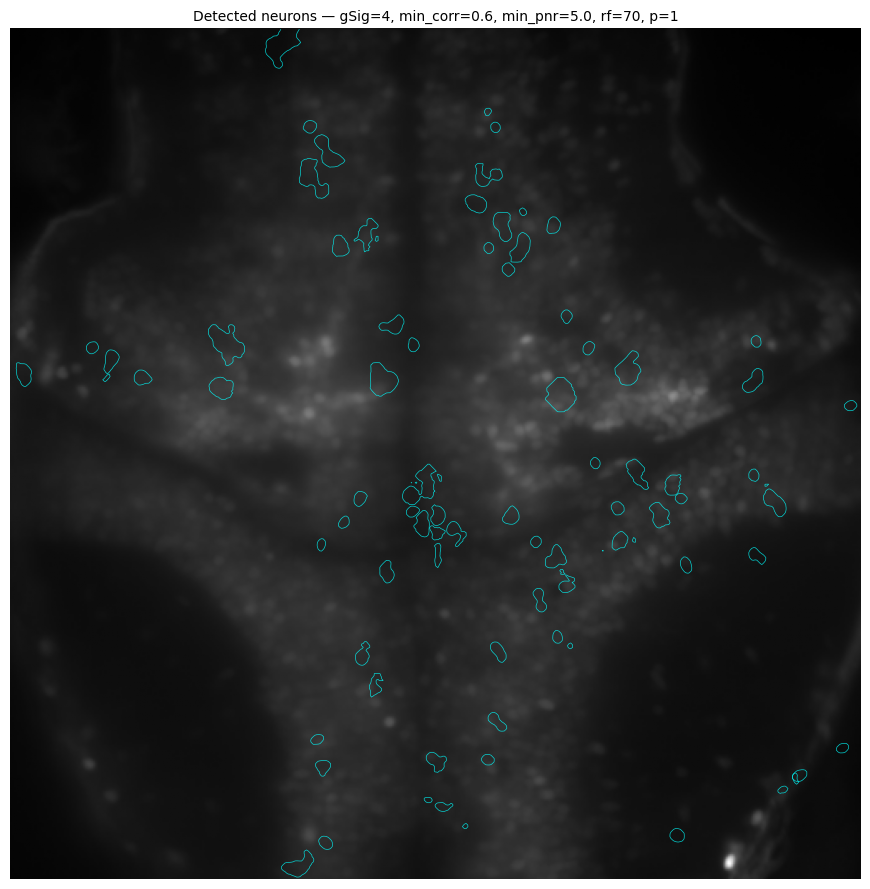

Saved final_neuron_contours.png


In [18]:
# %% cell9 — FINAL CNMF RUN WITH BEST PARAMETERS
# Runs CNMF once more with the chosen settings, then applies component
# evaluation to separate real neurons from noise components.
# =============================================================================

print("=" * 60)
print("FINAL CNMF RUN")
print("=" * 60)

final_run_params = {
    k: v
    for k, v in best_params.items()
    if k not in ("note", "split_half_stability")
}

cnmf_final, final_runtime = run_cnmf(final_run_params, FNAME_MMAP)

if cnmf_final is None:
    print("Final CNMF run failed. Review parameters and error messages above.")
else:
    n_total = cnmf_final.estimates.A.shape[1]
    print(f"Total components before filtering: {n_total}  ({final_runtime:.0f}s)")

    # Component evaluation: classify components as accepted / rejected
    # Uses SNR and spatial correlation with a smoothed neuron template.
    try:
        cnmf_final.estimates.evaluate_components(
            imgs=data_512,
            params=cnmf_final.params,
            dview=None,
        )
        cnmf_final.estimates.select_components(use_object=True)
        n_accepted = cnmf_final.estimates.A.shape[1]
        print(f"Accepted components after filtering: {n_accepted}")
    except Exception as exc:
        print(f"Component evaluation skipped ({exc}). Using all {n_total} components.")

    # Overlay neuron contours on the mean projection
    mean_frame = data_512.mean(axis=0)
    fig, ax = plt.subplots(figsize=(9, 9))
    ax.imshow(mean_frame, cmap="gray")
    ax.set_title(
        f"Detected neurons — gSig={BEST_GSIG}, min_corr={BEST_CORR}, "
        f"min_pnr={BEST_PNR}, rf={BEST_RF}, p={BEST_P}",
        fontsize=10,
    )
    ax.axis("off")

    H_val, W_val = DIMS_512
    for i in range(cnmf_final.estimates.A.shape[1]):
        fp = np.asarray(cnmf_final.estimates.A[:, i].todense()).flatten().reshape(H_val, W_val)
        if fp.max() == 0:
            continue
        ax.contour(fp, levels=[fp.max() * 0.5], colors="cyan", linewidths=0.5, alpha=0.8)

    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/final_neuron_contours.png", dpi=150)
    plt.show()
    print("Saved final_neuron_contours.png")


Saved final_traces.npy       shape=(59, 60)
Saved final_footprints.npy   shape=(262144, 59)


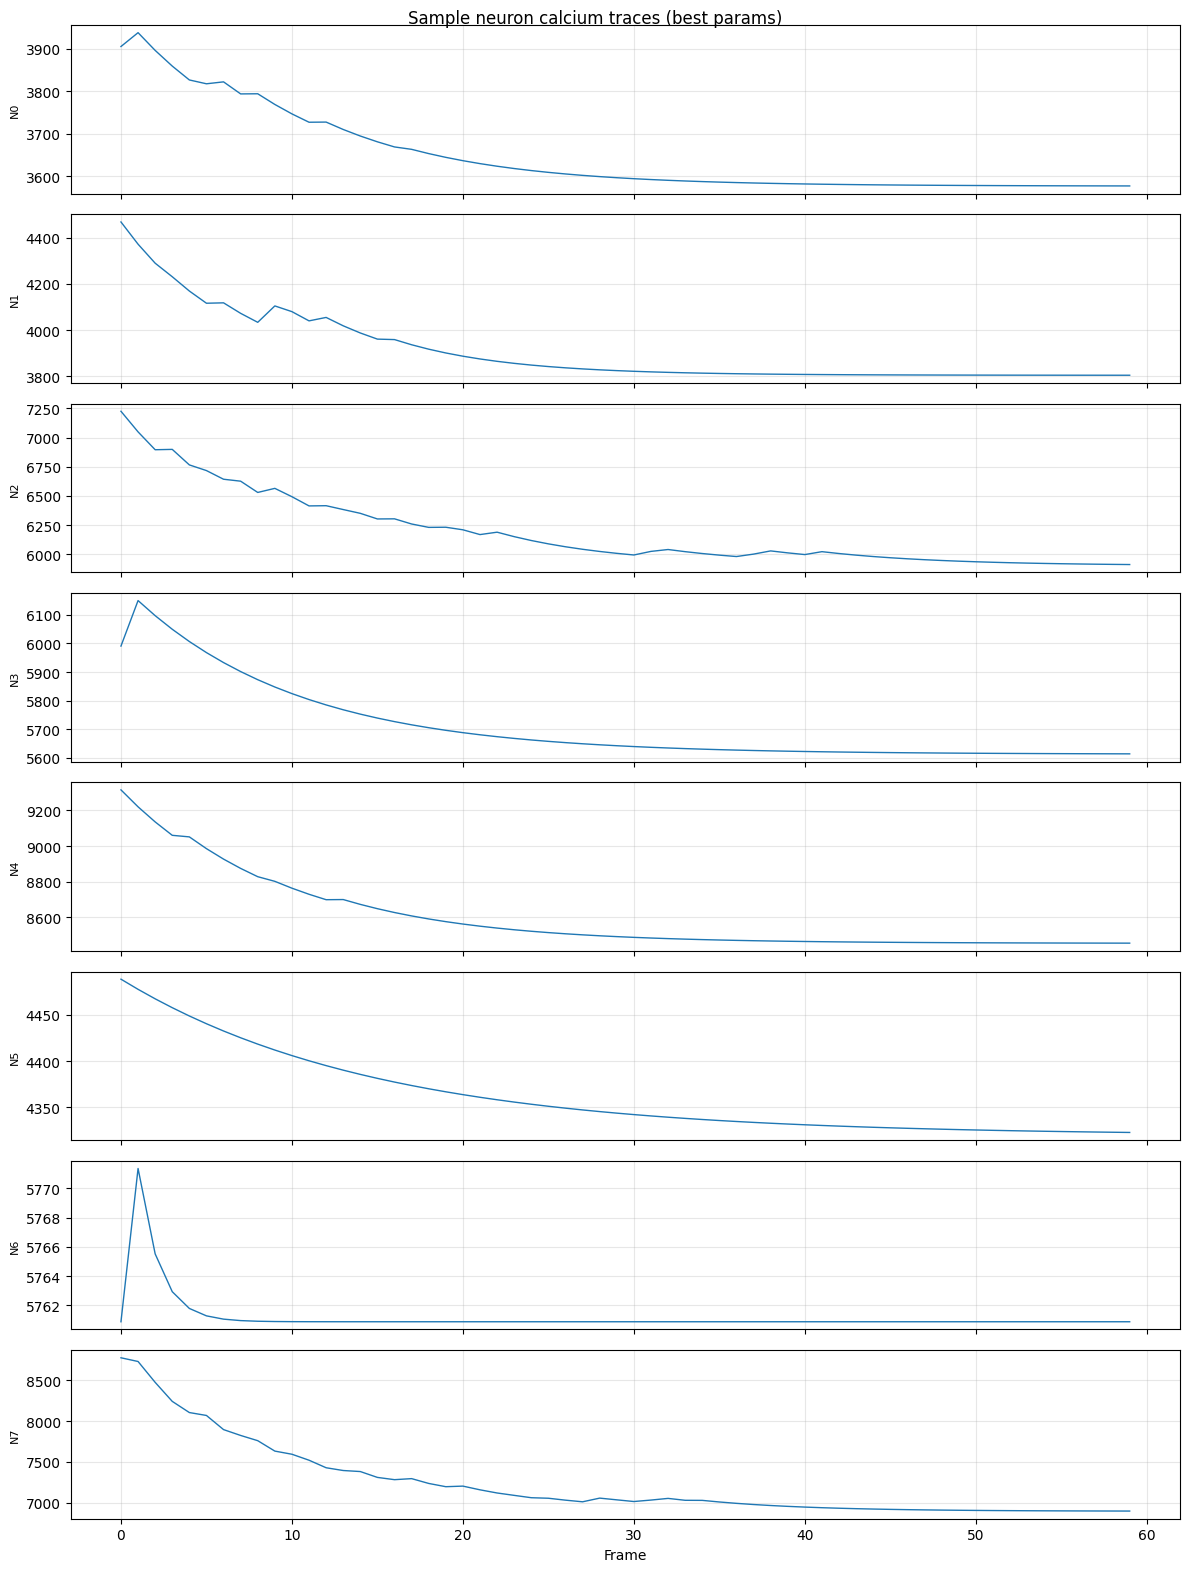

Saved sample_traces.png

All outputs written to /content/cnmf_results/
  exp1_gsig_sweep.csv
  exp2_threshold_grid.csv
  exp3_patch_size.csv
  exp4_ar_order.csv
  exp2_threshold_grid_heatmap.png
  best_params.json
  final_traces.npy          shape=(59, 60)
  final_footprints.npy      shape=(262144, 59)
  final_neuron_contours.png
  sample_traces.png


In [19]:
# %% cell10 — SAVE OUTPUTS AND PLOT SAMPLE TRACES
# =============================================================================

if cnmf_final is not None and cnmf_final.estimates.C.shape[0] > 0:
    traces          = cnmf_final.estimates.C                    # (n_neurons, T)
    footprints_sparse = cnmf_final.estimates.A                  # (d1*d2, n_neurons) sparse
    footprints_dense  = footprints_sparse.toarray()             # (d1*d2, n_neurons) dense

    np.save(f"{OUTPUT_DIR}/final_traces.npy",     traces)
    np.save(f"{OUTPUT_DIR}/final_footprints.npy", footprints_dense)
    print(f"Saved final_traces.npy       shape={traces.shape}")
    print(f"Saved final_footprints.npy   shape={footprints_dense.shape}")

    # Plot up to 8 sample neuron traces
    n_plot  = min(8, traces.shape[0])
    t_axis  = np.arange(T)
    fig, axes = plt.subplots(n_plot, 1, figsize=(12, 2 * n_plot), sharex=True)
    if n_plot == 1:
        axes = [axes]
    for i, ax in enumerate(axes):
        ax.plot(t_axis, traces[i], lw=1)
        ax.set_ylabel(f"N{i}", fontsize=8)
        ax.grid(True, alpha=0.3)
    axes[-1].set_xlabel("Frame")
    plt.suptitle("Sample neuron calcium traces (best params)")
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/sample_traces.png", dpi=120)
    plt.show()
    print("Saved sample_traces.png")

    print(f"\nAll outputs written to {OUTPUT_DIR}/")
    print("  exp1_gsig_sweep.csv")
    print("  exp2_threshold_grid.csv")
    print("  exp3_patch_size.csv")
    print("  exp4_ar_order.csv")
    print("  exp2_threshold_grid_heatmap.png")
    print("  best_params.json")
    print(f"  final_traces.npy          shape={traces.shape}")
    print(f"  final_footprints.npy      shape={footprints_dense.shape}")
    print("  final_neuron_contours.png")
    print("  sample_traces.png")
else:
    print("No outputs saved — final CNMF produced no accepted components.")
    print("Try lowering min_corr or min_pnr in best_params and re-running cell9.")
